## LSTM model on macroscopic data 

In this notebook, the LSTM model is trained on the macroscopic data with 2 different ways :

- First we will try to predict the value of A at time t from the value of A at time t-1 : ***A(t)= LSTM(A(t-1))***
- Secondly we will try to predict the difference between the value of A at time t and the value of A at time t-1 from the difference of the value A at time t-1 and its value at time t-2, since the previous experiments showed that the version containing lags worked better so we directly used this last: ***A(t+1) = A(t) + LSTM(A(t) - A(t-1), Lag5)***

#### Importing necessary libraries 

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time 
import os
import joblib


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
base_dir = "predictions"
model_name = "lstm"

model_dir = os.path.join(base_dir, model_name)
os.makedirs(model_dir, exist_ok=True)

#### Loading the data 

In [4]:
data_1 = pd.read_csv("./Macro_lag_1.csv")
data_1 = data_1.dropna()
data_1.head()

,t,A_sample_noisy,A_sample_lag1
1,62.0,0.976038,0.989995
2,122.0,0.976572,0.976038
3,182.0,0.968470,0.976572
4,242.0,0.954645,0.968470
5,302.0,0.951726,0.954645


In [5]:
data_3 = pd.read_csv("./Macro_lag_1_delta_y_delta_lags.csv")

data_3.head()

,t,A_sample_noisy,A_sample_lag1,delta_y,delta_y_lag1,delta_y_lag5
0,422.0,0.938089,0.942669,-0.004581,-0.009057,0.000534
1,482.0,0.929299,0.938089,-0.008790,-0.004581,-0.008102
2,542.0,0.924808,0.929299,-0.004491,-0.008790,-0.013825
3,602.0,0.926087,0.924808,0.001279,-0.004491,-0.002918
4,662.0,0.916821,0.926087,-0.009266,0.001279,-0.009057


In [6]:
data_3.shape

(140, 6)

### Functions and Definitions 

In [7]:
def mean_absolute_percentage_error(y_true, y_pred): 
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [10]:
def compute_smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(
        2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))
    ) * 100

In [11]:
def compute_nrmse(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return rmse / (np.max(y_true) - np.min(y_true)) 

In [12]:
def create_sequences(data, target_col, seq_length):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        print(data.iloc[i:i+seq_length].drop(columns=[target_col]).values)
        X.append(data.iloc[i:i+seq_length].drop(columns=[target_col]).values)
        y.append(data.iloc[i+seq_length][target_col])

    return np.array(X), np.array(y)

In [41]:
def create_sequences_univariate(data, seq_length=1):
    X, y = [], []
    if seq_length == 5:
        for i in range(len(data)):
            # select multiple columns as a row
            X.append(data[["delta_y_lag1","delta_y_lag5"]].iloc[i].values)
            y.append(data["delta_y"].iloc[i])
    else:
        for i in range(len(data)):
            X.append(data["delta_y_lag1"].iloc[i])
            y.append(data["delta_y"].iloc[i])
    return np.array(X), np.array(y)


In [14]:
def forecast_lstm(model, last_sequence, n_steps):
    
    preds = []
    current_seq = last_sequence.copy()

    for _ in range(n_steps):
        pred = model.predict(current_seq.reshape(1, current_seq.shape[0], current_seq.shape[1]), verbose=0)
        
        preds.append(pred)
        
        # slide window
        current_seq = pred

    return np.array(preds)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',   
    patience=20,          
    restore_best_weights=True  
)

In [18]:
def save_experiment_results(
    part,
    model_name,
    method,
    mae,
    nrmse,
    rmse,
    smape,
    r2,
    train_time,
    pred_time,
    file_path="../results.csv"
):
    new_data = {
        "part": part,
        "model": model_name,
        "method": method,
        "mae": mae,
        "nrmse": nrmse,
        "rmse": rmse,
        "smape": smape,
        "r2": r2,
        "train_time": train_time,
        "pred_time": pred_time
    }

    new_row = pd.DataFrame([new_data])

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df = pd.concat([df, new_row], ignore_index=True)
    else:
        df = new_row

    df.to_csv(file_path, index=False)

    print("Results saved successfully!")

In [19]:
def save_model(model, model_name, part, method, folder="../saved_models"):
    os.makedirs(folder, exist_ok=True)

    filename = f"{model_name}_{part}_{method}.pkl"
    path = os.path.join(folder, filename)

    joblib.dump(model, path)

    print(f"Model saved at: {path}")

### Data Preparation and Splitting 

###### Making the time columns as an index because we won't need it

In [20]:
data_1 = data_1.set_index('t')
data_3 = data_3.set_index('t')

###### Lets split the data into 80% training and 20% for testing

In [21]:
split = int(len(data_1) * 0.8)

train_1 = data_1.iloc[:split]
test_1  = data_1.iloc[split:]

In [22]:
print("train_1 shape : ", train_1.shape,"\n")
print("test_1 shape : ", test_1.shape,"\n")

train_1 shape :  (116, 2) 

test_1 shape :  (30, 2) 



In [23]:
split = int(len(data_3) * 0.8)

train_3, test_3 = data_3.iloc[:split], data_3.iloc[split:]

In [24]:
print("train_3 shape : ", train_3.shape,"\n")
print("test_3 shape : ", test_3.shape,"\n")

train_3 shape :  (112, 5) 

test_3 shape :  (28, 5) 



##### We should put our data into a numpy array with the correct shape for LSTM

In [39]:
#y_values_1 = data_1['A_sample_noisy'].values

X_1_train, y_1_train = create_sequences_univariate(train_1, seq_length=1)
X_1_test, y_1_test = create_sequences_univariate(test_1, seq_length=1)

In [43]:
#y_values = data_3['delta_y'].values

X_3_train, y_3_train = create_sequences_univariate(train_3, seq_length=5)
X_3_test, y_3_test = create_sequences_univariate(test_3, seq_length=5)

In [44]:
print("X_1 training shape : ",X_1_train.shape,"\n")
print("y_1 training shape : ",y_1_train.shape,"\n")
print("X_3 training shape : ",X_3_train.shape,"\n")
print("y_3 training shape : ",y_3_train.shape,"\n")

X_1 training shape :  (116,) 

y_1 training shape :  (116,) 

X_3 training shape :  (112, 2) 

y_3 training shape :  (112,) 



In [45]:
print("X_1 testing shape : ",X_1_test.shape,"\n")
print("y_1 testing shape : ",y_1_test.shape,"\n")
print("X_3 testing shape : ",X_3_test.shape,"\n")
print("y_3 testing shape : ",y_3_test.shape,"\n")

X_1 testing shape :  (30,) 

y_1 testing shape :  (30,) 

X_3 testing shape :  (28, 2) 

y_3 testing shape :  (28,) 



##### We will be using only data_1 and data_3 , so lets scale them

In [47]:
x_scaler_1 = StandardScaler()
y_scaler_1 = StandardScaler()

X_train_scaled_1 = x_scaler_1.fit_transform(X_1_train.reshape(-1, 1))
X_test_scaled_1 = x_scaler_1.transform(X_1_test.reshape(-1, 1))

y_train_scaled_1 = y_scaler_1.fit_transform(y_1_train.reshape(-1, 1))
y_test_scaled_1 = y_scaler_1.transform(y_1_test.reshape(-1, 1))

In [50]:
x_scaler_3 = StandardScaler()
y_scaler_3 = StandardScaler()

X_train_scaled_3 = x_scaler_3.fit_transform(X_3_train)
X_test_scaled_3 = x_scaler_3.transform(X_3_test)

y_train_scaled_3 = y_scaler_3.fit_transform(y_3_train.reshape(-1, 1))
y_test_scaled_3 = y_scaler_3.transform(y_3_test.reshape(-1, 1))

In [51]:
print("X_1 training shape : ",X_train_scaled_1.shape,"\n")
print("y_1 training shape : ",y_train_scaled_1.shape,"\n")
print("X_3 training shape : ",X_train_scaled_3.shape,"\n")
print("y_3 training shape : ",y_train_scaled_3.shape,"\n")

X_1 training shape :  (116, 1) 

y_1 training shape :  (116, 1) 

X_3 training shape :  (112, 2) 

y_3 training shape :  (112, 1) 



In [52]:
print("X_1 testing shape : ",X_test_scaled_1.shape,"\n")
print("y_1 testing shape : ",y_test_scaled_1.shape,"\n")
print("X_3 testing shape : ",X_test_scaled_3.shape,"\n")
print("y_3 testing shape : ",y_test_scaled_3.shape,"\n")

X_1 testing shape :  (30, 1) 

y_1 testing shape :  (30, 1) 

X_3 testing shape :  (28, 2) 

y_3 testing shape :  (28, 1) 



##### LSTM ready shapes

In [66]:
X_train_scaled_1 = X_train_scaled_1.reshape(-1, 1, 1)
y_train_scaled_1 = y_train_scaled_1.reshape(-1, 1, 1)
X_train_scaled_3 = X_train_scaled_3.reshape(-1, 1, 2)
y_train_scaled_3 = y_train_scaled_3.reshape(-1, 1, 1)

In [67]:
X_test_scaled_1 = X_test_scaled_1.reshape(-1, 1, 1)
y_test_scaled_1 = y_test_scaled_1.reshape(-1, 1, 1)
X_test_scaled_3 = X_test_scaled_3.reshape(-1, 1, 2)
y_test_scaled_3 = y_test_scaled_3.reshape(-1, 1, 1)

In [68]:
print(X_train_scaled_1.shape)
print(y_train_scaled_1.shape)
print(X_train_scaled_3.shape)
print(y_train_scaled_3.shape)

(116, 1, 1)
(116, 1, 1)
(112, 1, 2)
(112, 1, 1)


In [70]:
print(X_test_scaled_1.shape)
print(y_test_scaled_1.shape)
print(X_test_scaled_3.shape)
print(y_test_scaled_3.shape)

(30, 1, 1)
(30, 1, 1)
(28, 1, 2)
(28, 1, 1)


### Model Training

##### 1- First equation : ***A(t)= LSTM(A(t-1))***
f(lag1) → target

sample i:
timestep 0 → [x(t-1)] → predict x(t)

In [74]:
model_1 = Sequential()

model_1.add(LSTM(
    64,
    input_shape=(X_train_scaled_1.shape[1], X_train_scaled_1.shape[2]),
    return_sequences=True
))

model_1.add(LSTM(32, return_sequences=False))

model_1.add(Dropout(0.2))

model_1.add(Dense(1))

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=0.001),
    metrics=[RootMeanSquaredError()]
)

In [75]:
start_1 = time.perf_counter()
history_1 = model_1.fit(
    X_train_scaled_1,
    y_train_scaled_1,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_scaled_1, y_test_scaled_1), 
    shuffle=False,
    verbose=1,
    callbacks=[early_stop] 
)
end_1 = time.perf_counter()
elapsed_time_training_1 = end_1 - start_1

print(f"Execution time of the training: {elapsed_time_training_1:.4f} seconds")

Epoch 1/100
4/4 [==============================] - 14s 498ms/step - loss: 0.9895 - root_mean_squared_error: 0.9948 - val_loss: 3.3250 - val_root_mean_squared_error: 1.8235
Epoch 2/100
4/4 [==============================] - 0s 45ms/step - loss: 0.9704 - root_mean_squared_error: 0.9851 - val_loss: 3.2704 - val_root_mean_squared_error: 1.8084
Epoch 3/100
4/4 [==============================] - 0s 43ms/step - loss: 0.9536 - root_mean_squared_error: 0.9765 - val_loss: 3.2113 - val_root_mean_squared_error: 1.7920
Epoch 4/100
4/4 [==============================] - 0s 42ms/step - loss: 0.9348 - root_mean_squared_error: 0.9669 - val_loss: 3.1486 - val_root_mean_squared_error: 1.7744
Epoch 5/100
4/4 [==============================] - 0s 39ms/step - loss: 0.9176 - root_mean_squared_error: 0.9579 - val_loss: 3.0816 - val_root_mean_squared_error: 1.7555
Epoch 6/100
4/4 [==============================] - 0s 35ms/step - loss: 0.8997 - root_mean_squared_error: 0.9485 - val_loss: 3.0094 - val_root_mean_

Epoch 49/100
4/4 [==============================] - 0s 39ms/step - loss: 0.0129 - root_mean_squared_error: 0.1137 - val_loss: 0.0422 - val_root_mean_squared_error: 0.2054
Epoch 50/100
4/4 [==============================] - 0s 71ms/step - loss: 0.0107 - root_mean_squared_error: 0.1036 - val_loss: 0.0414 - val_root_mean_squared_error: 0.2035
Epoch 51/100
4/4 [==============================] - 0s 48ms/step - loss: 0.0117 - root_mean_squared_error: 0.1081 - val_loss: 0.0413 - val_root_mean_squared_error: 0.2033
Epoch 52/100
4/4 [==============================] - 0s 32ms/step - loss: 0.0114 - root_mean_squared_error: 0.1068 - val_loss: 0.0421 - val_root_mean_squared_error: 0.2053
Epoch 53/100
4/4 [==============================] - 0s 37ms/step - loss: 0.0086 - root_mean_squared_error: 0.0929 - val_loss: 0.0430 - val_root_mean_squared_error: 0.2075
Epoch 54/100
4/4 [==============================] - 0s 38ms/step - loss: 0.0103 - root_mean_squared_error: 0.1015 - val_loss: 0.0437 - val_root_m

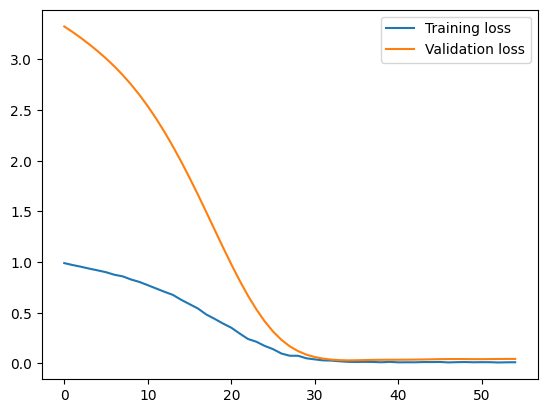

In [76]:
plt.plot(history_1.history['loss'], label='Training loss')
plt.plot(history_1.history['val_loss'], label='Validation loss')
plt.legend()

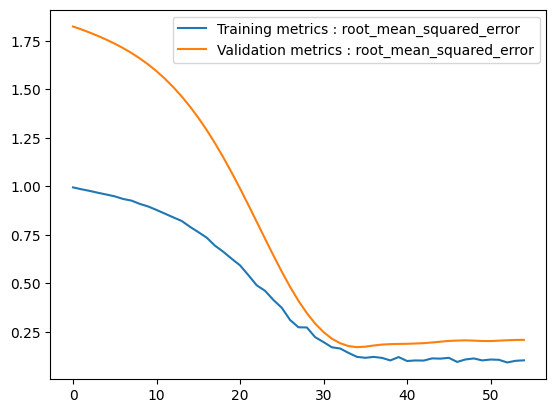

In [77]:
plt.plot(history_1.history['root_mean_squared_error'], label='Training metrics : root_mean_squared_error')
plt.plot(history_1.history['val_root_mean_squared_error'], label='Validation metrics : root_mean_squared_error')
plt.legend()

##### Visualizing the test predictions

In [79]:
predictions = model_1.predict(X_test_scaled_1)

1/1 [==============================] - 1s 866ms/step


In [80]:
predictions.shape

(30, 1)

In [82]:
trues_inv = y_scaler_1.inverse_transform(y_test_scaled_1.reshape(-1, 1))
preds_inv = y_scaler_1.inverse_transform(predictions.reshape(-1, 1))

Metrics

In [83]:
mse = mean_squared_error(trues_inv, preds_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(trues_inv, preds_inv)
r2 = r2_score(trues_inv, preds_inv)
mape = mean_absolute_percentage_error(trues_inv, preds_inv)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("Mape:",mape)

RMSE: 0.025492610937353614
MAE: 0.02372661311053694
R2: -0.6385495443093396
Mape: 5.677421638862436


Plots

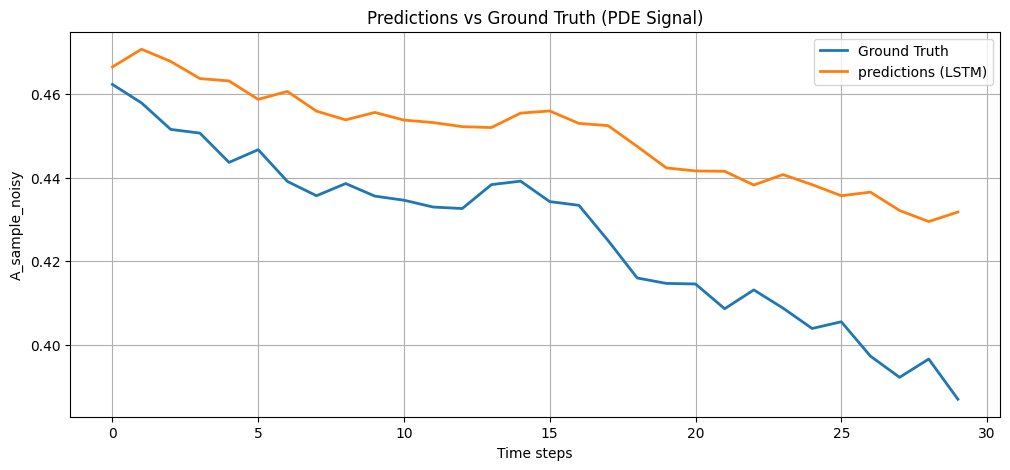

In [84]:
plt.figure(figsize=(12,5))

plt.plot(trues_inv, label='Ground Truth', linewidth=2)
plt.plot(preds_inv, label='predictions (LSTM)', linewidth=2)

plt.title('Predictions vs Ground Truth (PDE Signal)')
plt.xlabel('Time steps')
plt.ylabel('A_sample_noisy')

plt.legend()
plt.grid()

plt.show()

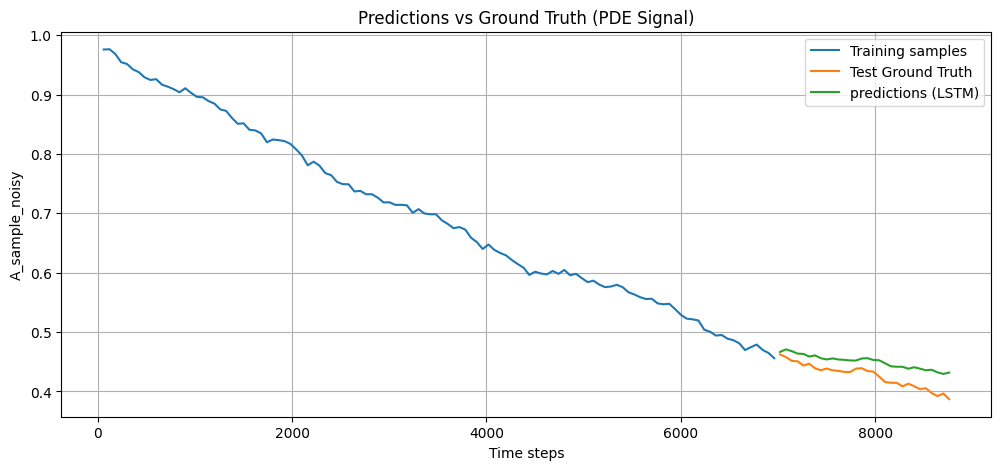

In [91]:
plt.figure(figsize=(12,5))
plt.plot(train_1.index,train_1["A_sample_noisy"],label='Training samples')
plt.plot(test_1.index,test_1["A_sample_noisy"],label='Test Ground Truth')
# plt.plot(test_1.index,trues_inv, label='Test inversed Ground Truth')
plt.plot(test_1.index,preds_inv, label='predictions (LSTM)')

plt.title('Predictions vs Ground Truth (PDE Signal)')
plt.xlabel('Time steps')
plt.ylabel('A_sample_noisy')

plt.legend()
plt.grid()

plt.show()

##### Making forcasts

In [92]:
history = train_1["A_sample_noisy"].copy()

In [98]:
history

t
62.0      0.976038
122.0     0.976572
182.0     0.968470
242.0     0.954645
302.0     0.951726
            ...   
6722.0    0.474669
6782.0    0.478973
6842.0    0.470036
6902.0    0.464928
6962.0    0.455930
Name: A_sample_noisy, Length: 116, dtype: float64

In [97]:
history.iloc[-1]

0.4559298076544595

In [117]:
his = list(history)

In [118]:
his[-1]

0.4559298076544595

In [119]:
n_steps = len(test_1)
predictions = []

for _ in range(n_steps):

    # build features from history
    lag1 = his[-1]
    print("lag",lag1)

    X_input = np.array([[lag1]])
    
    # scale input
    X_input_scaled = x_scaler_1.transform(X_input)

    # reshape for LSTM
    X_input_scaled = X_input_scaled.reshape((-1, 1, 1))
    print("shape of input",X_input_scaled.shape)
    
    # predict (scaled)
    y_pred_scaled = model_1.predict(X_input_scaled, verbose=0)
    print("y_predicted",y_pred_scaled)
    
    # reshape to 2D for inverse scaling
    y_pred_scaled_2d = y_pred_scaled.reshape(-1, 1)
    print("y_reshaped",y_pred_scaled_2d)
    
    # inverse scale
    y_pred = y_scaler_1.inverse_transform(y_pred_scaled_2d)[0, 0]
    print("finale predicted y",y_pred)
    # store prediction
    predictions.append(y_pred)

    # update history 
    his.append(y_pred)

lag 0.4559298076544595
shape of input (1, 1, 1)
y_predicted [[-1.5648103]]
y_reshaped [[-1.5648103]]
finale predicted y 0.46658686
lag 0.46658686
shape of input (1, 1, 1)
y_predicted [[-1.5172608]]
y_reshaped [[-1.5172608]]
finale predicted y 0.47364148
lag 0.47364148
shape of input (1, 1, 1)
y_predicted [[-1.4848175]]
y_reshaped [[-1.4848175]]
finale predicted y 0.4784549
lag 0.4784549
shape of input (1, 1, 1)
y_predicted [[-1.4622339]]
y_reshaped [[-1.4622339]]
finale predicted y 0.48180544
lag 0.48180544
shape of input (1, 1, 1)
y_predicted [[-1.4462979]]
y_reshaped [[-1.4462979]]
finale predicted y 0.48416978
lag 0.48416978
shape of input (1, 1, 1)
y_predicted [[-1.4349452]]
y_reshaped [[-1.4349452]]
finale predicted y 0.4858541
lag 0.4858541
shape of input (1, 1, 1)
y_predicted [[-1.4268038]]
y_reshaped [[-1.4268038]]
finale predicted y 0.48706198
lag 0.48706198
shape of input (1, 1, 1)
y_predicted [[-1.4209372]]
y_reshaped [[-1.4209372]]
finale predicted y 0.48793238
lag 0.487932

In [114]:
predictions

[0.46658686,
 0.47364148,
 0.4784549,
 0.48180544,
 0.48416978,
 0.4858541,
 0.48706198,
 0.48793238,
 0.48856172,
 0.48901784,
 0.48934904,
 0.4895898,
 0.48976502,
 0.4898926,
 0.48998556,
 0.49005333,
 0.4901027,
 0.49013874,
 0.49016502,
 0.4901842,
 0.49019817,
 0.49020836,
 0.49021578,
 0.49022123,
 0.4902252,
 0.4902281,
 0.49023017,
 0.4902317,
 0.49023283,
 0.49023363]

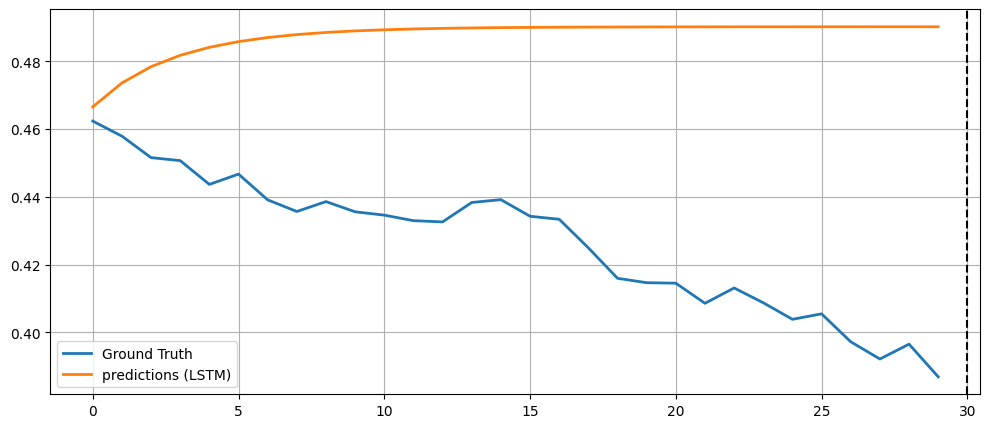

In [120]:
plt.figure(figsize=(12,5))

# full test signal
plt.plot(trues_inv, label='Ground Truth', linewidth=2)
plt.plot(predictions, label='predictions (LSTM)', linewidth=2)
plt.axvline(len(trues_inv), color='black', ls='--')

plt.legend()
plt.grid()
plt.show()

##### 3- Third equation : ***A(t+1) = A(t) + LSTM(A(t) - A(t-1), lag5)***

f(lag1, lag5) → target
* sample i:
* timestep 0 → [x(t-1), x(t-5)] → predict x(t)

In [163]:
model_3 = Sequential()

model_3.add(LSTM(
    64,
    input_shape=(X_train_scaled_3.shape[1], X_train_scaled_3.shape[2]),
    return_sequences=True
))

model_3.add(LSTM(32, return_sequences=False))

model_3.add(Dropout(0.2))

model_3.add(Dense(1))

model_3.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=0.001),
    metrics=[RootMeanSquaredError()]
)

In [165]:
model_3.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_10 (LSTM)              (None, 1, 64)             17152     
                                                                 
 lstm_11 (LSTM)              (None, 32)                12416     
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29,601
Trainable params: 29,601
Non-trainable params: 0
_________________________________________________________________


In [132]:
history_2=[]

In [133]:
start_2 = time.perf_counter()
history_2 = model_3.fit(
    X_train_scaled_3,
    y_train_scaled_3,
    epochs=1000,
    batch_size=8,
    validation_data=(X_test_scaled_3, y_test_scaled_3), 
    shuffle=False,
    verbose=1,
    callbacks=[early_stop] 
)
end_2 = time.perf_counter()
elapsed_time_training_2 = end_2 - start_2

print(f"Execution time of the training: {elapsed_time_training_1:.4f} seconds")

Epoch 1/1000
14/14 [==============================] - 5s 107ms/step - loss: 0.9840 - root_mean_squared_error: 0.9920 - val_loss: 0.7608 - val_root_mean_squared_error: 0.8723
Epoch 2/1000
14/14 [==============================] - 0s 24ms/step - loss: 0.9565 - root_mean_squared_error: 0.9780 - val_loss: 0.7498 - val_root_mean_squared_error: 0.8659
Epoch 3/1000
14/14 [==============================] - 0s 23ms/step - loss: 0.9261 - root_mean_squared_error: 0.9623 - val_loss: 0.7398 - val_root_mean_squared_error: 0.8601
Epoch 4/1000
14/14 [==============================] - 0s 22ms/step - loss: 0.8888 - root_mean_squared_error: 0.9427 - val_loss: 0.7308 - val_root_mean_squared_error: 0.8548
Epoch 5/1000
14/14 [==============================] - 0s 22ms/step - loss: 0.8604 - root_mean_squared_error: 0.9276 - val_loss: 0.7283 - val_root_mean_squared_error: 0.8534
Epoch 6/1000
14/14 [==============================] - 0s 22ms/step - loss: 0.8285 - root_mean_squared_error: 0.9102 - val_loss: 0.7363

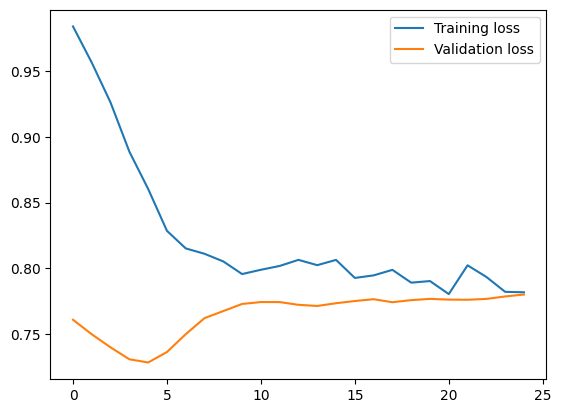

In [134]:
plt.plot(history_2.history['loss'], label='Training loss')
plt.plot(history_2.history['val_loss'], label='Validation loss')
plt.legend()

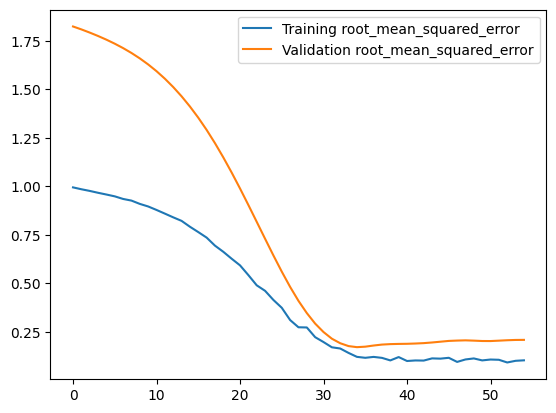

In [135]:
plt.plot(history_1.history['root_mean_squared_error'], label='Training root_mean_squared_error')
plt.plot(history_1.history['val_root_mean_squared_error'], label='Validation root_mean_squared_error')
plt.legend()

###### Making predictions

In [136]:
predictions = model_3.predict(X_test_scaled_3)

1/1 [==============================] - 1s 1s/step


In [137]:
predictions.shape

(28, 1)

In [138]:
trues_inv_3 = y_scaler_3.inverse_transform(y_test_scaled_3.reshape(-1, 1))
preds_inv_3 = y_scaler_3.inverse_transform(predictions.reshape(-1, 1))

Metrics

In [139]:
mse = mean_squared_error(trues_inv, preds_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(trues_inv, preds_inv)
r2 = r2_score(trues_inv, preds_inv)
mape = mean_absolute_percentage_error(trues_inv, preds_inv)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("Mape:",mape)

RMSE: 0.025492610937353614
MAE: 0.02372661311053694
R2: -0.6385495443093396
Mape: 5.677421638862436


Plots

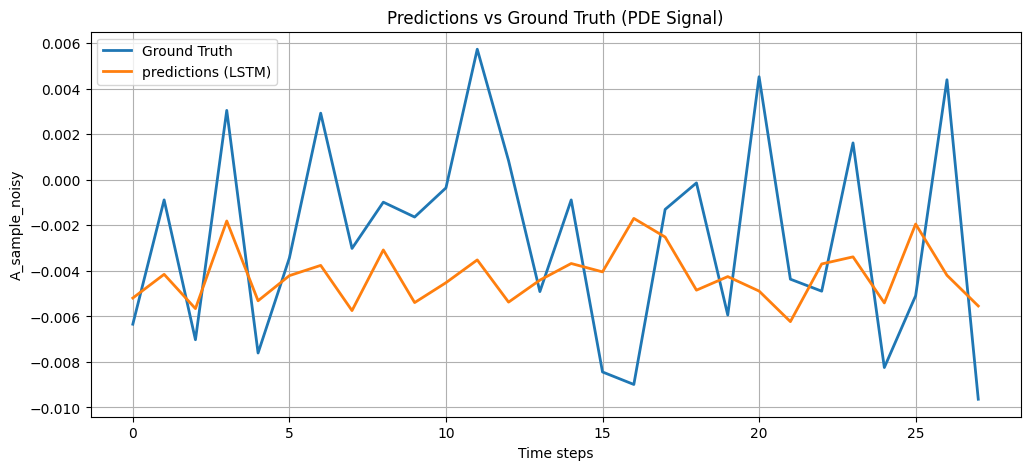

In [141]:
plt.figure(figsize=(12,5))

plt.plot(trues_inv_3, label='Ground Truth', linewidth=2)
plt.plot(preds_inv_3, label='predictions (LSTM)', linewidth=2)

plt.title('Predictions vs Ground Truth (PDE Signal)')
plt.xlabel('Time steps')
plt.ylabel('A_sample_noisy')

plt.legend()
plt.grid()

plt.show()

###### Making forcasts

In [142]:
history = train_3["delta_y"].copy()

In [143]:
history = list(history)

In [144]:
history

[-0.0045808256874427,
 -0.0087895229274156,
 -0.0044909495632927,
 0.0012792038996014,
 -0.009266083110706,
 -0.003346705555481,
 -0.0041906290283951,
 -0.0052797328061305,
 0.006805598543675,
 -0.0079339231646428,
 -0.0065792111280936,
 -0.0007100674916552,
 -0.0064858175235437,
 -0.0041963196380404,
 -0.0097643131725229,
 -0.0024712422386208,
 -0.0119074843639095,
 -0.0098236244978228,
 0.000744942565284,
 -0.0108830956341604,
 -0.0009892656808054,
 -0.005091576857186,
 -0.0148977350102529,
 0.0045755583221568,
 -0.0009499319382744,
 -0.0016990568541644,
 -0.004529290935992,
 -0.009328909515535,
 -0.0102660004167148,
 -0.0166732206052853,
 0.0061561059544347,
 -0.0066118723748983,
 -0.012612989569704,
 -0.0034379317591954,
 -0.0113383053806778,
 -0.0038437062583214,
 -0.0001922158806666,
 -0.012109191483262,
 0.0009689469155143,
 -0.0057581357306653,
 0.0001162249772278,
 -0.0058060629279437,
 -0.0080368937724786,
 0.0002738673211467,
 -0.0043451367715112,
 5.031267522814797e-05,
 -0

In [146]:
n_steps = len(test_3) 
predictions = []
start_3 = time.perf_counter()
for _ in range(n_steps):

    # build features from history
    lag1 = history[-1]
    lag5 = history[-5]

    X_input = np.array([[lag1, lag5]])

    # scale input
    X_input_scaled = x_scaler_3.transform(X_input)

    # reshape for LSTM
    X_input_scaled = X_input_scaled.reshape((1, 1, 2))

    # predict (scaled)
    y_pred_scaled = model_3.predict(X_input_scaled, verbose=0)

    # reshape to 2D for inverse scaling
    y_pred_scaled_2d = y_pred_scaled.reshape(-1, 1)

    # inverse scale
    y_pred = y_scaler_3.inverse_transform(y_pred_scaled_2d)[0, 0]

    # store prediction
    predictions.append(y_pred)

    # update history
    history.append(y_pred)
    
reconstructed = predictions + test_3["A_sample_lag1"].reset_index(drop=True)

end_3 = time.perf_counter()
elapsed_time_preds_3 = end_3 - start_3

print(f"Execution time of the training: {elapsed_time_preds_3:.4f} seconds")

Execution time of the training: 2.9168 seconds


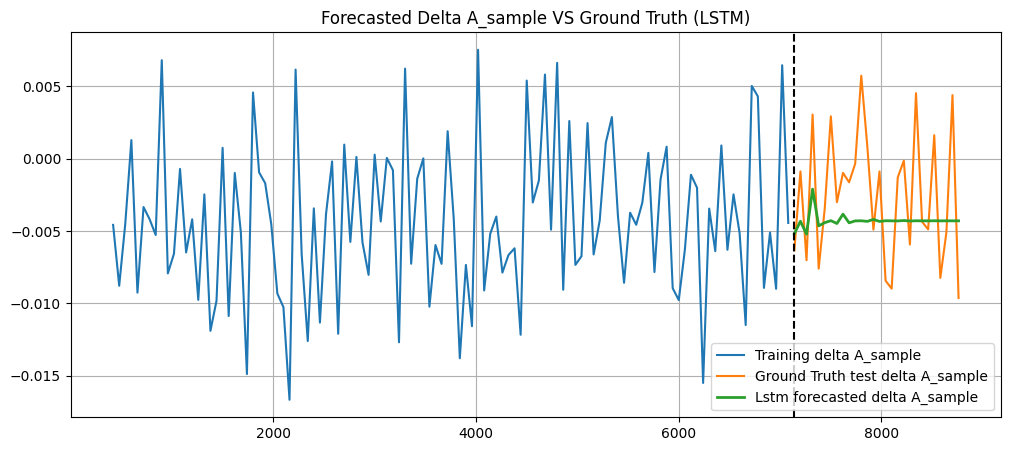

In [155]:
plt.figure(figsize=(12,5))
plt.plot(train_3.index,train_3["delta_y"],label='Training delta A_sample')
plt.plot(test_3.index,trues_inv_3, label='Ground Truth test delta A_sample')
plt.plot(test_3.index,predictions, label='Lstm forecasted delta A_sample', linewidth=2)
plt.axvline(7142, color='black', ls='--')
plt.title("Forecasted Delta A_sample VS Ground Truth (LSTM)")
plt.legend()
plt.grid()
plt.show()

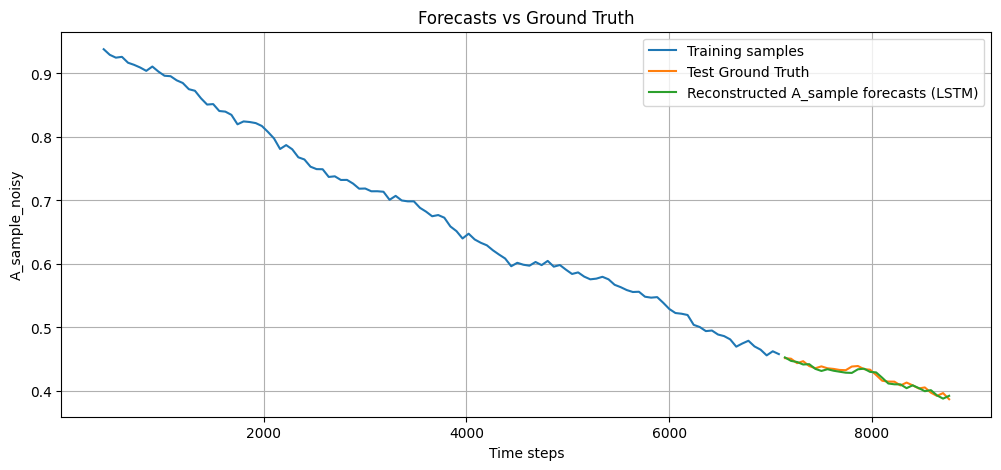

In [156]:
plt.figure(figsize=(12,5))
plt.plot(train_3.index,train_3["A_sample_noisy"],label='Training samples')
plt.plot(test_3.index,test_3["A_sample_noisy"],label='Test Ground Truth')
# plt.plot(test_1.index,trues_inv, label='Test inversed Ground Truth')
plt.plot(test_3.index,reconstructed, label='Reconstructed A_sample forecasts (LSTM)')

plt.title('Forecasts vs Ground Truth')
plt.xlabel('Time steps')
plt.ylabel('A_sample_noisy')

plt.legend()
plt.grid()

plt.show()

In [157]:
y_test = test_3['A_sample_noisy'].values
y_pred = reconstructed
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
smape = compute_smape(y_test, y_pred)
nrmse = compute_nrmse(y_test,y_pred)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("sMape:",smape)
print('NRMSE',nrmse)

RMSE: 0.0045502538021927694
MAE: 0.0037473083421974735
R2: 0.938567140067155
sMape: 0.8913656097105146
NRMSE 0.07031839882546408


#### Save Results and models 

In [158]:
save_experiment_results(
    part="macro",
    model_name="lstm",
    method="predict_delta_y", 
    mae=mae,
    nrmse=nrmse,
    rmse=rmse,
    smape=smape,
    r2=r2,
    train_time=elapsed_time_training_2,
    pred_time=elapsed_time_preds_3
)

Results saved successfully!


In [159]:
save_model(
    model=model_3,
    model_name="lstm",
    part="macro",
    method="predict_delta_y"
)

INFO:tensorflow:Assets written to: ram://ac2641f4-2999-4fd9-853e-866e857ddb85/assets


INFO:tensorflow:Assets written to: ram://ac2641f4-2999-4fd9-853e-866e857ddb85/assets


Model saved at: ../saved_models\lstm_macro_predict_delta_y.pkl


In [162]:
results_df = pd.DataFrame({
    "y_true": test_3['delta_y'].values,
    "y_pred": predictions,
    "reconstructed" : reconstructed.values 
})

results_df.to_csv(os.path.join(model_dir, "predictions_lstm_target_delta_y.csv"), index=False)